1. UPsampling : increase minority points
2. DOWNsampling: decrease majority datapoints

In [3]:
import numpy as np 
import pandas as pd 

In [4]:
np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)

n_class_1 = n_samples - n_class_0

In [5]:
n_class_0, n_class_1

(900, 100)

In [6]:
#CREATE DATAFRAME WITH IMBALANCED DATASET 

class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc =0, scale =1 , size = n_class_0),
    'feature_2' : np.random.normal(loc =0, scale =1 , size = n_class_0),
    'target' : [0] * n_class_0
        })

class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc =0, scale =1 , size = n_class_1),
    'feature_2' : np.random.normal(loc =0, scale =1 , size = n_class_1),
    'target' : [1] * n_class_1
        })

In [7]:
df = pd.concat([class_0, class_1]).reset_index(drop= True)

In [8]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [9]:
df.tail()

,feature_1,feature_2,target
995,-0.623629,0.845701,1
996,0.239810,-1.119923,1
997,-0.868240,-0.359297,1
998,0.902006,-1.609695,1
999,0.697490,0.013570,1


In [10]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [11]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

# upscaling


In [20]:
from sklearn.utils import resample #it extrapolates or generate more likely poinyts to minority to equilise with majority


df_minority_upsampled =resample(df_minority,replace =True, #sample with replacement as we want to increase the datapoints
                               n_samples = len(df_majority),
                                random_state= 41) 

In [13]:
df_minority_upsampled.head()

,feature_1,feature_2,target
964,0.397060,-1.259772,1
935,1.869809,-0.472381,1
912,0.834499,0.773754,1
998,0.902006,-1.609695,1
980,-1.553578,0.342423,1


In [19]:
df_minority_upsampled['target'].value_counts()

target
1    900
Name: count, dtype: int64

In [30]:
final_df = pd.concat([df_majority,df_minority_upsampled]).reset_index()
final_df

,index,feature_1,feature_2,target
0,0,-1.085631,0.551302,0
1,1,0.997345,0.419589,0
2,2,0.282978,1.815652,0
3,3,-1.506295,-0.252750,0
4,4,-0.578600,-0.292004,0
...,...,...,...,...
1795,932,-0.084530,-0.347959,1
1796,920,0.406071,0.418004,1
1797,970,-0.131240,-1.548765,1
1798,915,1.519471,-2.233905,1


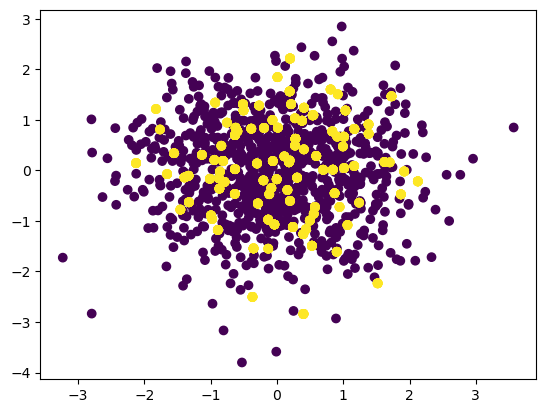

In [33]:
import matplotlib.pyplot as plt
plt.scatter(final_df['feature_1'],final_df['feature_2'], c=final_df['target'])

# downsampling


In [23]:

df_majority_downsampled =resample(df_minority,replace = False, #sample without replacement as we want to reduce the datapoints
                               n_samples = len(df_minority),
                                random_state= 41) 

In [25]:
df_majority_downsampled.shape

(100, 3)

In [28]:
pd.concat([df_majority_downsampled,df_minority]).reset_index()

,index,feature_1,feature_2,target
0,942,1.621531,0.168229,1
1,994,0.007714,1.847453,1
2,937,-0.931596,1.343388,1
3,906,0.555489,-0.856650,1
4,979,-1.131957,0.309863,1
...,...,...,...,...
195,995,-0.623629,0.845701,1
196,996,0.239810,-1.119923,1
197,997,-0.868240,-0.359297,1
198,998,0.902006,-1.609695,1
